# EDA USD/BRL pelo SCAN

**S — Stakeholder goals.** Entender a cobertura e a qualidade do histórico diário USD/BRL antes de modelar o fechamento do próximo pregão. OKR: decidir uma política explícita de preparação sem alterar o CSV bruto. KPIs: cobertura >2 anos, datas únicas/ordenadas, contagem de faltantes e valores inválidos, distribuição dos fechamentos e retornos. A EDA examina somente os primeiros 80% das observações válidas; lote novo (5%), promoção (5%) e teste final (10%) não entram nas estatísticas e gráficos.

**C — Columns and coverage.** Conferir tipos, período, frequência observada, ausências e constância de colunas.

**A — Aggregates and anomalies.** Resumos descritivos, extremos e retornos entre observações válidas.

**N — Notable segments.** Comparar anos e inspecionar graficamente a série e os retornos. As conclusões de limpeza cabem à revisão humana antes do treino.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd()
root = cwd.parent if cwd.name == 'notebooks' else cwd
raw_path = root / 'data/raw/usd_brl_daily.csv'
if not raw_path.exists():
    raise FileNotFoundError(raw_path)
raw = pd.read_csv(raw_path, parse_dates=['Date'])
valid_dates = raw.loc[raw.Close.notna(), 'Date'].sort_values().reset_index(drop=True)
development_end = int(len(valid_dates) * 0.80)
development_cutoff = valid_dates.iloc[development_end-1]
print('Janelas fora da EDA: lote novo, promoção e teste final; apenas cortes/contagens:', len(valid_dates)-development_end, 'observações válidas a partir de', valid_dates.iloc[development_end].date())
df = raw.loc[raw.Date <= development_cutoff].copy()
print('Período de desenvolvimento:', df.Date.min().date(), 'a', df.Date.max().date(), '| linhas:', len(df))
print('Duplicatas de data no desenvolvimento:', df.Date.duplicated().sum())
print('Ordenado no arquivo bruto até o cutoff:', df.Date.is_monotonic_increasing)
df = df.sort_values('Date').reset_index(drop=True)
print('Tipos e ausências:')
display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'faltantes': df.isna().sum(), 'valores_únicos': df.nunique(dropna=True)}))
print('Dias úteis sem observação (inclui feriados):', len(pd.bdate_range(df.Date.min(), df.Date.max()).difference(df.Date)))
print('Frequência observada por dia da semana:')
display(df.Date.dt.day_name().value_counts().sort_index())
print('Intervalos entre datas observadas (dias):')
display(df.Date.diff().dt.days.value_counts().sort_index())
print('Preços não positivos:')
display((df[['Open', 'High', 'Low', 'Close']] <= 0).sum())
print('Datas com Close ausente:')
display(df.loc[df.Close.isna(), ['Date', 'Open', 'High', 'Low', 'Close']])


Janelas fora da EDA: lote novo, promoção e teste final; apenas cortes/contagens: 195 observações válidas a partir de 2026-01-05
Período de desenvolvimento: 2023-01-02 a 2026-01-02 | linhas: 785
Duplicatas de data no desenvolvimento: 0
Ordenado no arquivo bruto até o cutoff: True
Tipos e ausências:


,dtype,faltantes,valores_únicos
Date,datetime64[us],0,785
Open,float64,5,761
High,float64,5,754
Low,float64,5,773
Close,float64,5,762
Volume,float64,5,1


Dias úteis sem observação (inclui feriados): 0
Frequência observada por dia da semana:


Date
Friday       157
Monday       157
Thursday     157
Tuesday      157
Wednesday    157
Name: count, dtype: int64

Intervalos entre datas observadas (dias):


Date
1.0    628
3.0    156
Name: count, dtype: int64

Preços não positivos:


Open     0
High     0
Low      0
Close    0
dtype: int64

Datas com Close ausente:


,Date,Open,High,Low,Close
522,2025-01-01,NaN,NaN,NaN,NaN
599,2025-04-18,NaN,NaN,NaN,NaN
600,2025-04-21,NaN,NaN,NaN,NaN
778,2025-12-25,NaN,NaN,NaN,NaN
783,2026-01-01,NaN,NaN,NaN,NaN


Fechamento e retorno entre observações válidas:


,Close,return_pct
count,780.000000,779.000000
mean,5.320906,0.008610
std,0.356341,0.789378
min,4.723300,-3.246137
1%,4.769225,-1.932461
5%,4.852370,-1.156081
50%,5.327450,-0.016997
95%,5.953725,1.319326
99%,6.156640,2.200632
max,6.300000,3.719501


Por ano:


,registros,mínimo,mediana,máximo,retorno_médio_pct
year,,,,,
2023,260,4.7233,4.967600,5.4785,-0.030285
2024,262,4.8505,5.425213,6.2889,0.095508
2025,257,5.2707,5.551003,6.3000,-0.043647
2026,1,5.5170,5.517000,5.5170,0.745044


Maiores movimentos absolutos:


,Date,Close,return_pct
590,2025-04-07,5.84003,3.719501
593,2025-04-10,5.81810,-3.246137
513,2024-12-19,6.28890,3.042665
725,2025-10-13,5.52300,2.711442
658,2025-07-10,5.58180,2.491687
568,2025-03-06,5.74010,-2.473798
765,2025-12-08,5.43810,2.425930
566,2025-03-04,6.02050,2.382491
524,2025-01-03,6.15100,-2.365082
5,2023-01-09,5.22440,-2.344014


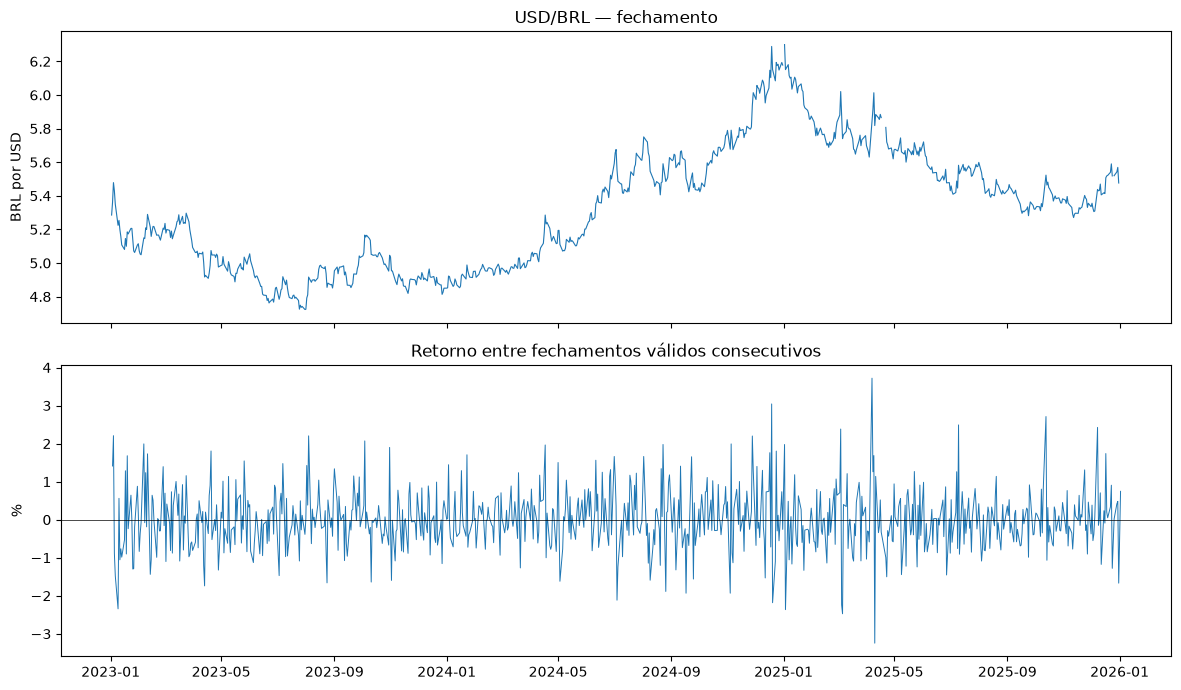

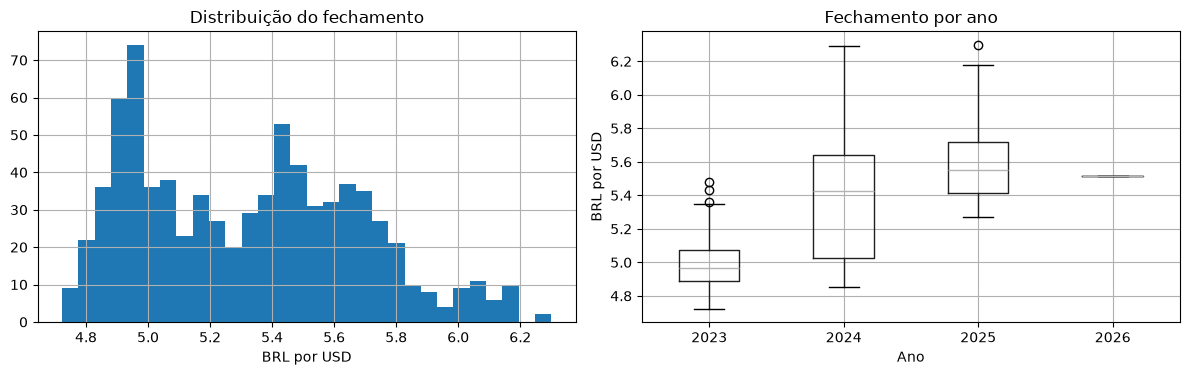

In [2]:
valid = df.dropna(subset=['Close']).copy()
valid['return_pct'] = valid.Close.pct_change() * 100
valid['year'] = valid.Date.dt.year
print('Fechamento e retorno entre observações válidas:')
display(valid[['Close', 'return_pct']].describe(percentiles=[.01, .05, .5, .95, .99]))
print('Por ano:')
display(valid.groupby('year').agg(registros=('Close', 'size'), mínimo=('Close', 'min'), mediana=('Close', 'median'), máximo=('Close', 'max'), retorno_médio_pct=('return_pct', 'mean')))
print('Maiores movimentos absolutos:')
display(valid.loc[valid.return_pct.abs().nlargest(10).index, ['Date', 'Close', 'return_pct']])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.Date, df.Close, linewidth=.8)
axes[0].set(title='USD/BRL — fechamento', ylabel='BRL por USD')
axes[1].plot(valid.Date, valid.return_pct, linewidth=.7)
axes[1].axhline(0, color='black', linewidth=.5)
axes[1].set(title='Retorno entre fechamentos válidos consecutivos', ylabel='%')
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
valid.Close.hist(ax=axes[0], bins=30)
axes[0].set(title='Distribuição do fechamento', xlabel='BRL por USD')
valid.boxplot(column='Close', by='year', ax=axes[1])
axes[1].set(title='Fechamento por ano', xlabel='Ano', ylabel='BRL por USD')
fig.suptitle('')
plt.tight_layout()
plt.show()


## Decisão de preparação para revisão

Proposta para revisão do estudante: usar somente `Date` e `Close` no treino e remover linhas com `Close` ausente **em uma cópia**, porque Prophet exige alvo numérico. `Volume` parece não trazer informação nesta série. Não imputar preços nem remover extremos sem decisão fundamentada após esta EDA. `bdate_range` marca também feriados, portanto lacunas ali não equivalem automaticamente a erro.